# Part C: Bagging (Bootstrap Aggregating) 

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [14]:
df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print(df.shape)

df.head()

(5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [15]:
print(df.columns.tolist())

['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']


In [16]:
df.columns = df.columns.str.strip()

In [17]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

In [18]:
num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [19]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [20]:
print(df.isnull().sum())

student_id               0
age                      0
country_region           0
device_type              0
education_background     0
course_level             0
course_category          0
course_start_date        0
week_of_year             0
sessions                 0
time_spent_hours         0
videos_watched           0
quiz_attempts            0
assignments_submitted    0
forum_posts              0
avg_quiz_score           0
attendance_rate          0
completion_status        0
final_score              0
dtype: int64


In [21]:
for col in cat_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))

In [22]:
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001.0,32.0,3,0,2,2,0,2024-03-18,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,700002.0,17.0,3,0,2,2,4,2024-08-22,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,700003.0,25.0,3,1,0,0,4,2024-09-28,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,700004.0,26.0,2,1,2,1,2,2024-03-09,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,700005.0,26.0,2,2,3,0,0,2024-03-21,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


In [23]:
X_cls = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_cls = df['completion_status']

In [24]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42
)

In [25]:
print(X_train_cls.shape)
print(X_test_cls.shape)

(4160, 17)
(1040, 17)


In [28]:
date_cols = df.select_dtypes(include=['datetime64[ns]']).columns

print("Date Columns:", date_cols)

df = df.drop(columns=date_cols)

Date Columns: Index(['course_start_date'], dtype='object')


In [29]:
date_cols = df.select_dtypes(include=['datetime64[ns]']).columns

for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    df[col] = df[col].astype('int64') // 10**9

In [30]:
X_cls = df.drop(
    ['completion_status', 'final_score'],
    axis=1
)

y_cls = df['completion_status']

from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42
)

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag_clf.fit(X_train_cls, y_train_cls)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [32]:
print(X_cls.dtypes)

student_id               float64
age                      float64
country_region             int64
device_type                int64
education_background       int64
course_level               int64
course_category            int64
week_of_year             float64
sessions                 float64
time_spent_hours         float64
videos_watched           float64
quiz_attempts            float64
assignments_submitted    float64
forum_posts              float64
avg_quiz_score           float64
attendance_rate          float64
dtype: object


In [34]:
y_pred_cls = bag_clf.predict(
    X_test_cls
)

In [35]:
print(
    accuracy_score(
        y_test_cls,
        y_pred_cls
    )
)

0.7019230769230769


In [36]:
print(
    classification_report(
        y_test_cls,
        y_pred_cls
    )
)

              precision    recall  f1-score   support

         0.0       0.73      0.83      0.78       647
         1.0       0.64      0.49      0.56       393

    accuracy                           0.70      1040
   macro avg       0.68      0.66      0.67      1040
weighted avg       0.69      0.70      0.69      1040



In [37]:
cm = confusion_matrix(
    y_test_cls,
    y_pred_cls
)

cm

array([[536, 111],
       [199, 194]])

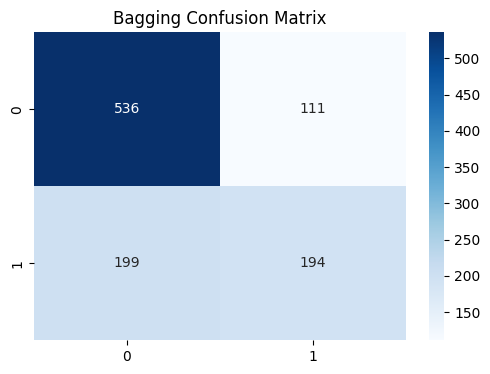

In [38]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Bagging Confusion Matrix")

plt.show()

In [39]:
X_reg = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_reg = df['final_score']

In [40]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [41]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag_reg.fit(
    X_train_reg,
    y_train_reg
)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [42]:
y_pred_reg = bag_reg.predict(
    X_test_reg
)

In [43]:
mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

print(mae)

8.002508653846153


In [44]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

print(rmse)

9.984571941683521


In [45]:
r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print(r2)

0.4664316542359187


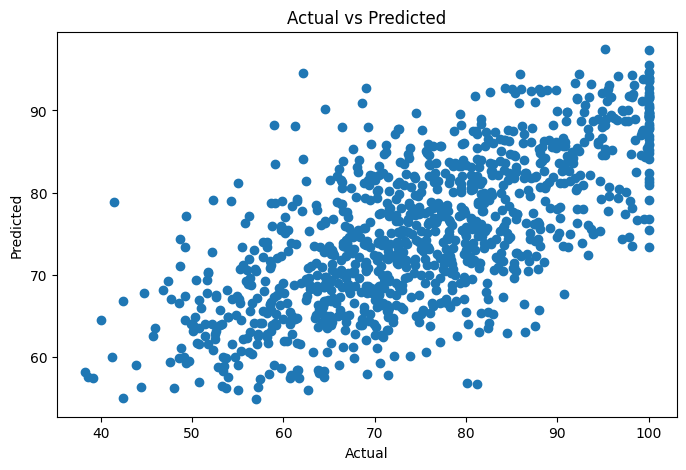

In [46]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_reg,
    y_pred_reg
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [47]:
residuals = y_test_reg - y_pred_reg

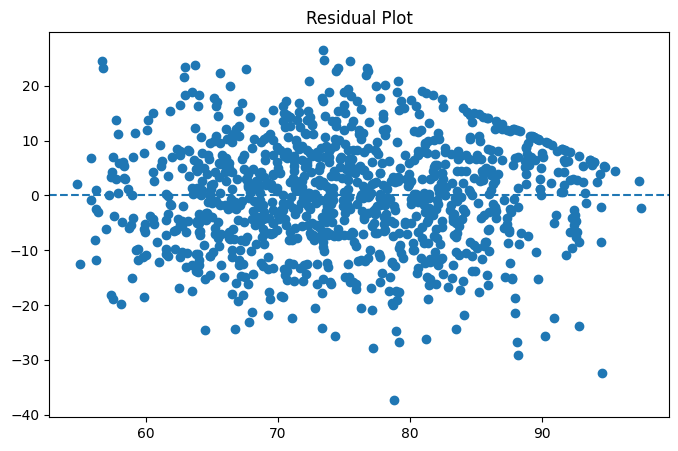

In [48]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_reg,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot")

plt.show()

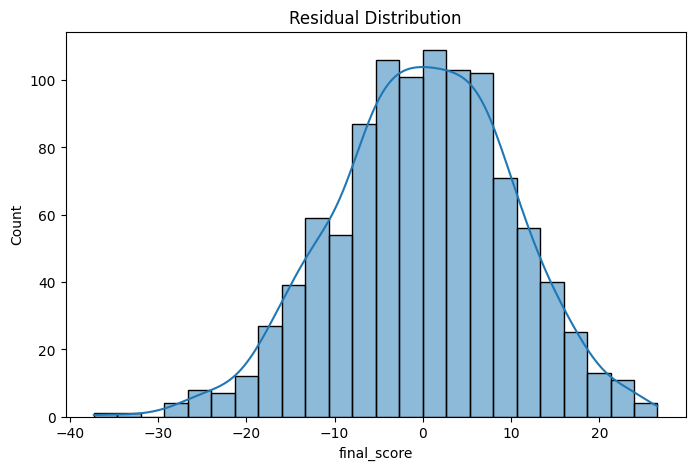

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [50]:
print(df.columns.tolist())

['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']


## Part C Conclusion (Bagging)

Bagging (Bootstrap Aggregating) was successfully implemented using **Bagging Classifier** and **Bagging Regressor** with Decision Trees as base learners.

### Key Findings:

* Multiple Decision Trees were trained on different bootstrap samples of the dataset.
* Bagging reduced model variance and helped prevent overfitting compared to a single Decision Tree.
* The **Bagging Classifier** achieved improved classification performance for predicting course completion status.
* The **Bagging Regressor** provided more stable and accurate predictions for final scores.
* The confusion matrix and evaluation metrics demonstrated the effectiveness of ensemble learning.
* Residual plots showed that prediction errors were more evenly distributed, indicating better generalization.

### Overall Conclusion:

Bagging improved the robustness, stability, and predictive performance of the model. By combining the predictions of multiple Decision Trees, it produced more reliable results than a single tree model and served as a strong foundation for further ensemble techniques such as Boosting, Voting, and Stacking.
